# NYC Citi Bike Trip Data Project

In [20]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import zipfile

In [22]:
folders = [
    "data/raw",
    "data/processed",
    "data/external"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [8]:
import requests

url = "https://s3.amazonaws.com/tripdata/202401-citibike-tripdata.zip"

print("Starting download...")

response = requests.get(url, timeout=60)

print("Download completed")
print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Starting download...
Download completed
Status code: 200
File size: 369035302 bytes


In [17]:
zip_path = "data/raw/202401-citibike-tripdata.zip"

with open(zip_path, "wb") as file:
    file.write(response.content)

print("ZIP file downloaded successfully!")

ZIP file downloaded successfully!


In [25]:
extract_path = "data/raw/202401"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '202403-citibike-tripdata (1).zip'

In [26]:
files = os.listdir(extract_path)

for file in files:
    print(file)

202401-citibike-tripdata_1.csv
202401-citibike-tripdata_2.csv


In [27]:
csv_files = []

for file in os.listdir(extract_path):
    if file.endswith(".csv"):
        csv_files.append(os.path.join(extract_path, file))

print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(file)

Number of CSV files: 2
data/raw/202401\202401-citibike-tripdata_1.csv
data/raw/202401\202401-citibike-tripdata_2.csv


In [28]:
df = pd.read_csv(csv_files[0])

print(df.head())

C:\Users\yuvra\AppData\Local\Temp\ipykernel_12644\2490700513.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_files[0])


            ride_id  rideable_type               started_at  \
0  8E865410DBDE0CA9  electric_bike  2024-01-01 13:00:04.563   
1  0403D0B3FC9CA77D  electric_bike  2024-01-08 19:36:43.520   
2  F6DE7BB42FF550BE  electric_bike  2024-01-12 15:00:41.580   
3  84A995BFD98030D4   classic_bike  2024-01-12 16:52:19.025   
4  7BBEAD4F2B535813  electric_bike  2024-01-05 19:50:19.202   

                  ended_at           start_station_name start_station_id  \
0  2024-01-01 13:04:04.652                 3 St & 3 Ave          4028.03   
1  2024-01-08 19:53:16.266  Franklin Ave & St Marks Ave          4107.05   
2  2024-01-12 15:36:29.622           W 67 St & Broadway          7116.04   
3  2024-01-12 17:17:29.773  Central Park West & W 68 St          7079.06   
4  2024-01-05 20:34:42.517           W 67 St & Broadway          7116.04   

            end_station_name end_station_id  start_lat  start_lng    end_lat  \
0      Carroll St & Smith St        4225.14  40.675070 -73.987752  40.680611   
1   

# Data Cleaning

In [29]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member


In [30]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
df.columns.tolist()

Rows: 1000000
Columns: 13

Columns:


['ride_id',
 'rideable_type',
 'started_at',
 'ended_at',
 'start_station_name',
 'start_station_id',
 'end_station_name',
 'end_station_id',
 'start_lat',
 'start_lng',
 'end_lat',
 'end_lng',
 'member_casual']

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1000000 non-null  object 
 1   rideable_type       1000000 non-null  object 
 2   started_at          1000000 non-null  object 
 3   ended_at            1000000 non-null  object 
 4   start_station_name  999424 non-null   object 
 5   start_station_id    999424 non-null   object 
 6   end_station_name    996936 non-null   object 
 7   end_station_id      996936 non-null   object 
 8   start_lat           999424 non-null   float64
 9   start_lng           999424 non-null   float64
 10  end_lat             996948 non-null   float64
 11  end_lng             996948 non-null   float64
 12  member_casual       1000000 non-null  object 
dtypes: float64(4), object(9)
memory usage: 99.2+ MB


In [32]:
missing = df.isnull().sum()

print(missing)

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     576
start_station_id       576
end_station_name      3064
end_station_id        3064
start_lat              576
start_lng              576
end_lat               3052
end_lng               3052
member_casual            0
dtype: int64


In [33]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent.sort_values(ascending=False))

end_station_name      0.3064
end_station_id        0.3064
end_lat               0.3052
end_lng               0.3052
start_station_name    0.0576
start_station_id      0.0576
start_lat             0.0576
start_lng             0.0576
ride_id               0.0000
rideable_type         0.0000
started_at            0.0000
ended_at              0.0000
member_casual         0.0000
dtype: float64


In [34]:
dataframes = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    dataframes.append(temp_df)

df_january = pd.concat(dataframes, ignore_index=True)

print("Total rows:", len(df_january))
print("Total columns:", len(df_january.columns))

C:\Users\yuvra\AppData\Local\Temp\ipykernel_12644\3437644785.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)
C:\Users\yuvra\AppData\Local\Temp\ipykernel_12644\3437644785.py:4: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file)


Total rows: 1888085
Total columns: 13


In [35]:
print(df_january.head())
print(df_january.columns.tolist())

            ride_id  rideable_type               started_at  \
0  8E865410DBDE0CA9  electric_bike  2024-01-01 13:00:04.563   
1  0403D0B3FC9CA77D  electric_bike  2024-01-08 19:36:43.520   
2  F6DE7BB42FF550BE  electric_bike  2024-01-12 15:00:41.580   
3  84A995BFD98030D4   classic_bike  2024-01-12 16:52:19.025   
4  7BBEAD4F2B535813  electric_bike  2024-01-05 19:50:19.202   

                  ended_at           start_station_name start_station_id  \
0  2024-01-01 13:04:04.652                 3 St & 3 Ave          4028.03   
1  2024-01-08 19:53:16.266  Franklin Ave & St Marks Ave          4107.05   
2  2024-01-12 15:36:29.622           W 67 St & Broadway          7116.04   
3  2024-01-12 17:17:29.773  Central Park West & W 68 St          7079.06   
4  2024-01-05 20:34:42.517           W 67 St & Broadway          7116.04   

            end_station_name end_station_id  start_lat  start_lng    end_lat  \
0      Carroll St & Smith St        4225.14  40.675070 -73.987752  40.680611   
1   

In [36]:
pip install pyarrow

In [37]:
# Fix mixed data types before saving as Parquet

for col in df_january.columns:
    if df_january[col].dtype == "object":
        df_january[col] = df_january[col].astype(str)

# Save as Parquet
output_path = "data/processed/2024-01-citibike.parquet"

df_january.to_parquet(
    output_path,
    index=False
)

print("Parquet file saved successfully!")

Parquet file saved successfully!


In [38]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [39]:
df_test = pd.read_parquet(output_path)
df_test.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member


In [40]:
df_test.shape

(1888085, 13)

In [41]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

In [42]:
df = df.drop_duplicates()

In [43]:
df.shape

(1000000, 13)

In [44]:
df.isnull().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name     576
start_station_id       576
end_station_name      3064
end_station_id        3064
start_lat              576
start_lng              576
end_lat               3052
end_lng               3052
member_casual            0
dtype: int64

In [45]:
df.shape

(1000000, 13)

In [46]:
df["started_at"] = pd.to_datetime(
    df["started_at"],
    errors="coerce"
)

df["ended_at"] = pd.to_datetime(
    df["ended_at"],
    errors="coerce"
)

In [47]:
df["trip_duration_minutes"] = (
    df["ended_at"] - df["started_at"]
).dt.total_seconds() / 60

In [48]:
print(df["trip_duration_minutes"].head())

0     4.001483
1    16.545767
2    35.800700
3    25.179133
4    44.388583
Name: trip_duration_minutes, dtype: float64


In [49]:
df = df[
    (df["trip_duration_minutes"] >= 1) &
    (df["trip_duration_minutes"] <= 480)
]
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual,4.001483
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual,16.545767
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual,35.800700
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member,25.179133
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member,44.388583


# Feature Engineering

In [50]:
df["hour"] = df["started_at"].dt.hour
df["hour"]

0         13
1         19
2         15
3         16
4         19
          ..
999995     8
999996     8
999997    14
999998     9
999999     9
Name: hour, Length: 999149, dtype: int32

In [51]:
df["day"] = df["started_at"].dt.day
df["day"]

0          1
1          8
2         12
3         12
4          5
          ..
999995    19
999996    23
999997    21
999998    23
999999    26
Name: day, Length: 999149, dtype: int32

In [52]:
df["month"] = df["started_at"].dt.month
df["month"]

0         1
1         1
2         1
3         1
4         1
         ..
999995    1
999996    1
999997    1
999998    1
999999    1
Name: month, Length: 999149, dtype: int32

In [53]:
df["day_of_week"] = df["started_at"].dt.day_name()
df["day_of_week"] 

0          Monday
1          Monday
2          Friday
3          Friday
4          Friday
           ...   
999995     Friday
999996    Tuesday
999997     Sunday
999998    Tuesday
999999     Friday
Name: day_of_week, Length: 999149, dtype: object

In [54]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes,hour,day,month,day_of_week
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual,4.001483,13,1,1,Monday
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual,16.545767,19,8,1,Monday
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual,35.800700,15,12,1,Friday
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member,25.179133,16,12,1,Friday
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member,44.388583,19,5,1,Friday


In [55]:
print("Code started")

df = df.dropna()

print("After removing missing values:", df.shape)

Code started
After removing missing values: (996119, 18)


In [56]:
print("Before:", df.shape)

df = df.dropna(subset=["started_at", "ended_at"])

print("After:", df.shape)

Before: (996119, 18)
After: (996119, 18)


In [57]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'trip_duration_minutes', 'hour', 'day', 'month',
       'day_of_week'],
      dtype='object')

In [58]:
df.shape

(996119, 18)

In [59]:
df.isnull().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name       0
start_station_id         0
end_station_name         0
end_station_id           0
start_lat                0
start_lng                0
end_lat                  0
end_lng                  0
member_casual            0
trip_duration_minutes    0
hour                     0
day                      0
month                    0
day_of_week              0
dtype: int64

In [60]:
df.duplicated().sum()

0

In [61]:
df.isna().sum()

ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name       0
start_station_id         0
end_station_name         0
end_station_id           0
start_lat                0
start_lng                0
end_lat                  0
end_lng                  0
member_casual            0
trip_duration_minutes    0
hour                     0
day                      0
month                    0
day_of_week              0
dtype: int64

In [62]:
df = df.dropna()

In [63]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_minutes,hour,day,month,day_of_week
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual,4.001483,13,1,1,Monday
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual,16.545767,19,8,1,Monday
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual,35.800700,15,12,1,Friday
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member,25.179133,16,12,1,Friday
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member,44.388583,19,5,1,Friday


In [ ]:
# Save the Dataset

df.to_excel("citibike_cleaned.xlsx",index=False)
print("Cleaned data saved successfully!")

# EDA Visualizations

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

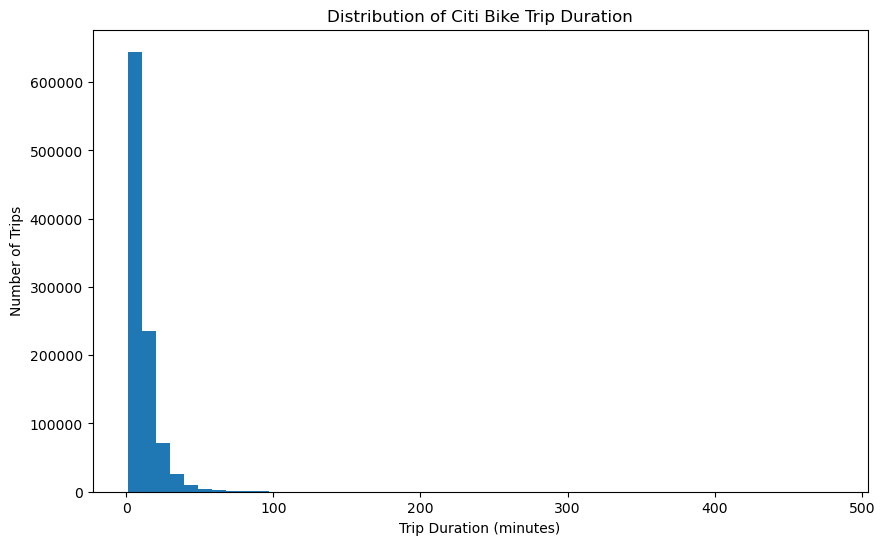

In [65]:
# 1. Distribution of trip duration

plt.figure(figsize=(10, 6))

plt.hist(
    df["trip_duration_minutes"],
    bins=50
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Number of Trips")
plt.title("Distribution of Citi Bike Trip Duration")

plt.show()

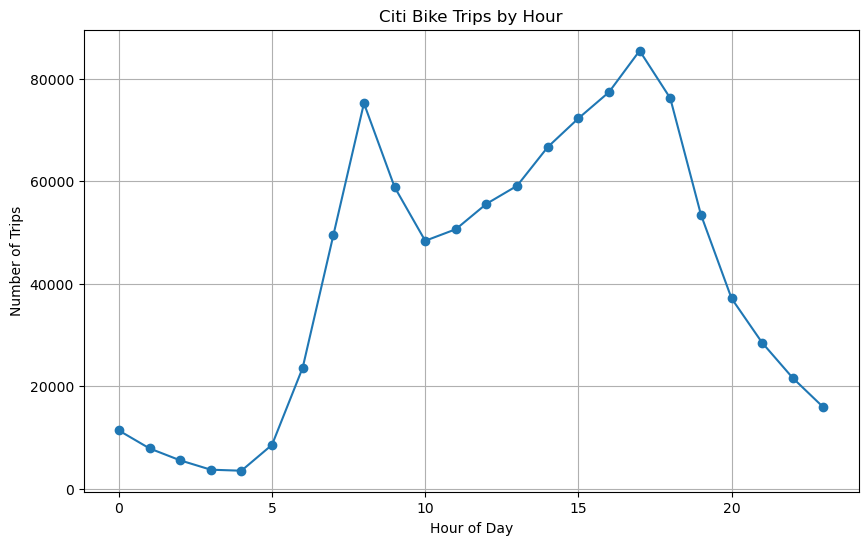

In [66]:
# 2. Number of trips by hour

hourly_trips = df.groupby("hour").size()

plt.figure(figsize=(10, 6))

hourly_trips.plot(
    kind="line",
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Hour")

plt.grid()

plt.show()

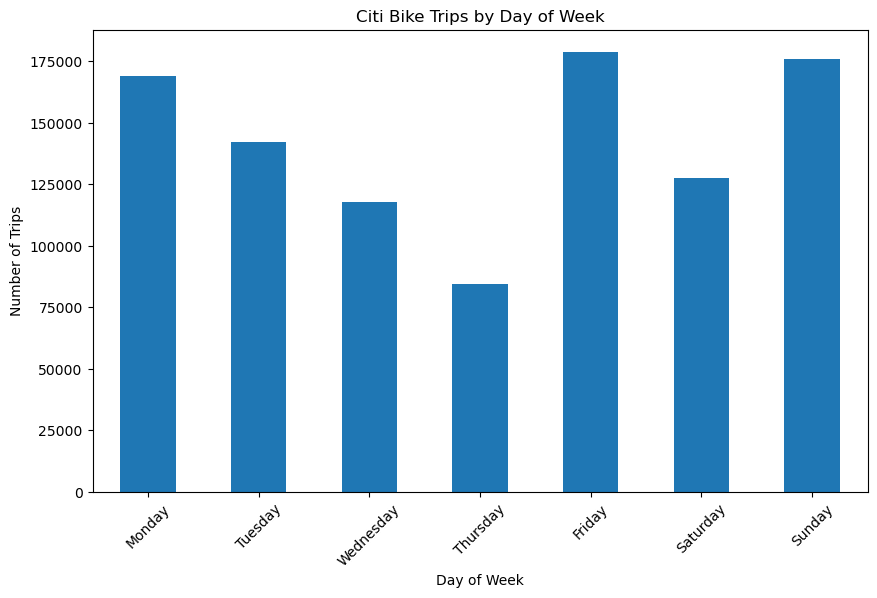

In [67]:
# 3. Number of trips by day of week

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_trips = (
    df.groupby("day_of_week")
    .size()
)

day_trips.index = day_names

plt.figure(figsize=(10, 6))

day_trips.plot(
    kind="bar"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Citi Bike Trips by Day of Week")

plt.xticks(rotation=45)

plt.show()

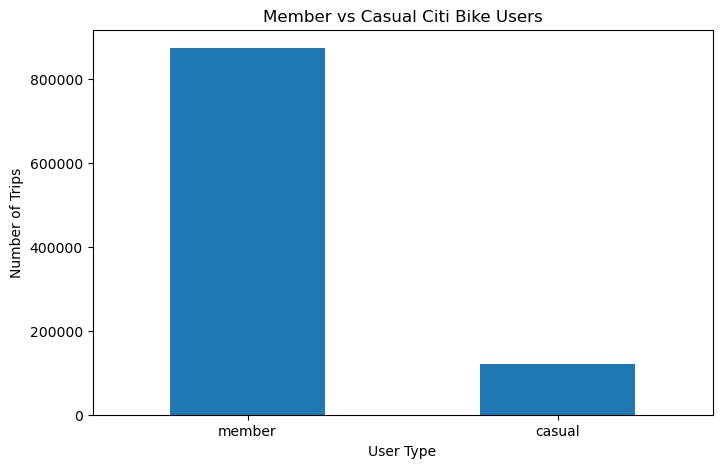

In [68]:
# 4. Member vs Casual riders

user_counts = (
    df["member_casual"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

user_counts.plot(
    kind="bar"
)

plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.title("Member vs Casual Citi Bike Users")

plt.xticks(rotation=0)

plt.show()

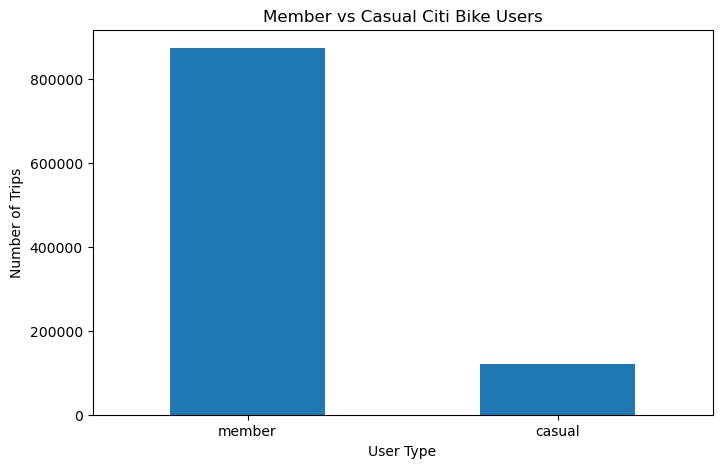

In [69]:
# 4. Member vs Casual riders

user_counts = (
    df["member_casual"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

user_counts.plot(
    kind="bar"
)

plt.xlabel("User Type")
plt.ylabel("Number of Trips")
plt.title("Member vs Casual Citi Bike Users")

plt.xticks(rotation=0)

plt.show()

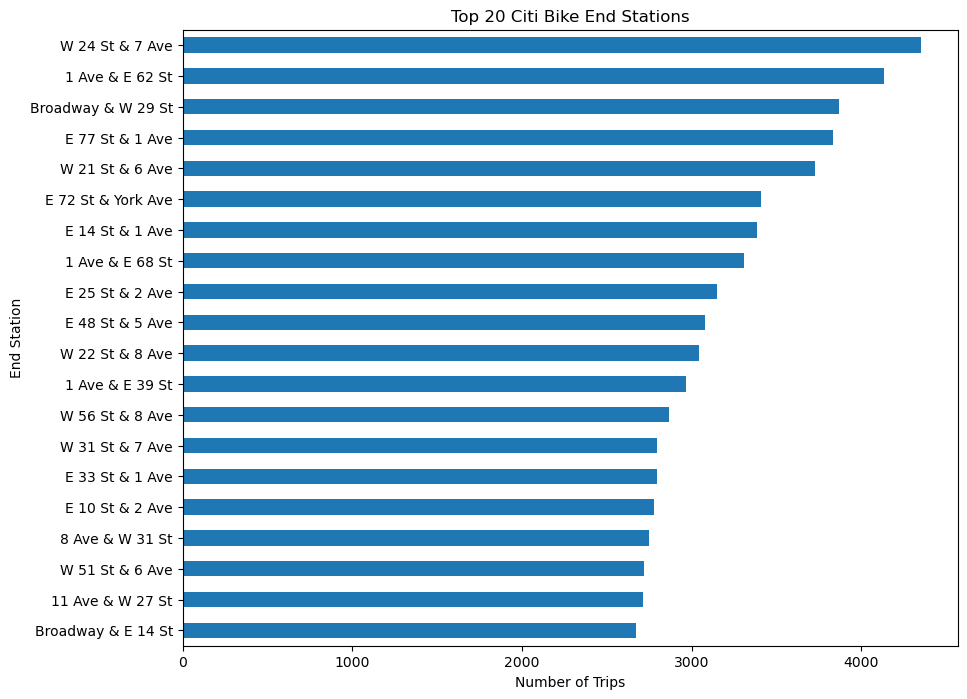

In [70]:
# 6. Top 20 most popular end stations

top_end = (
    df["end_station_name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 8))

top_end.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Trips")
plt.ylabel("End Station")
plt.title("Top 20 Citi Bike End Stations")

plt.show()

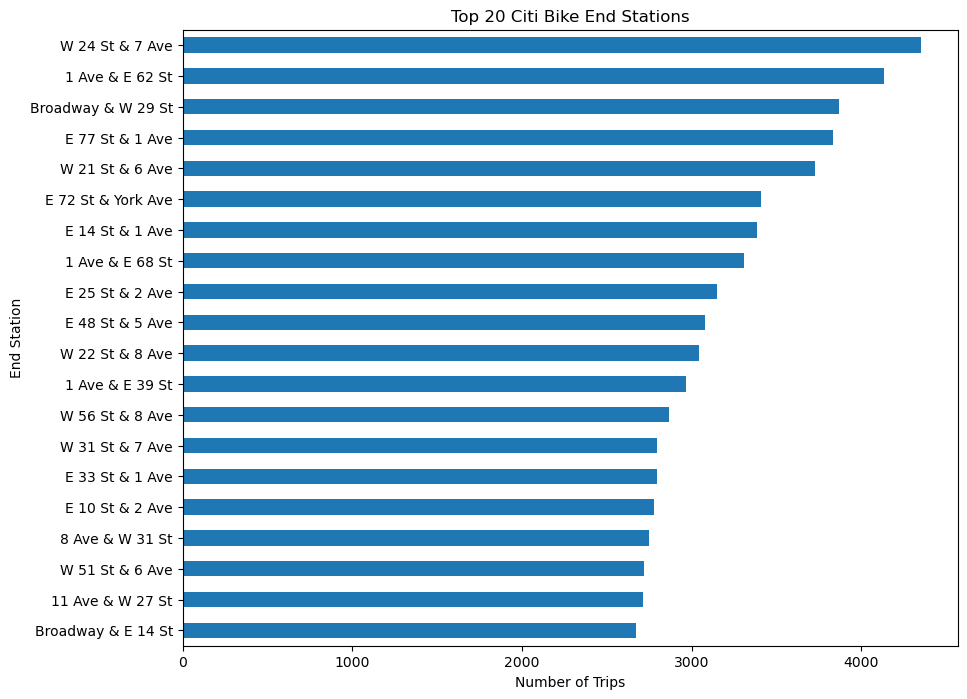

In [71]:
# 6. Top 20 most popular end stations

top_end = (
    df["end_station_name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 8))

top_end.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of Trips")
plt.ylabel("End Station")
plt.title("Top 20 Citi Bike End Stations")

plt.show()

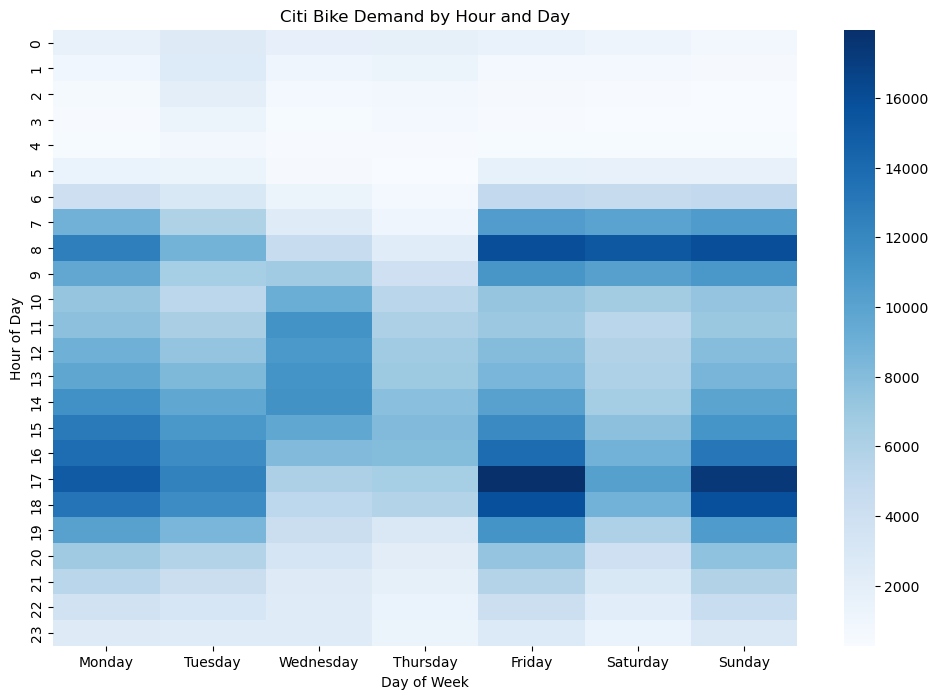

In [73]:
# 9. Heatmap of trips by hour and day of week

heatmap_data = pd.crosstab(
    df["hour"],
    df["day_of_week"]
)

heatmap_data.columns = day_names

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    cmap="Blues"
)

plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.title("Citi Bike Demand by Hour and Day")

plt.show()